# House Price Prediction

**Objective:** Predict house prices using property features like size, bedrooms, and location.
**Dataset:** House Price Prediction Dataset (Kaggle)
**Models Used:** Linear Regression, Gradient Boosting Regressor

In [3]:
#importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [4]:
dataset=pd.read_csv("House data.csv") # Load dataset

In [5]:
dataset.columns # Display column names

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country',
       'price'],
      dtype='object')

In [6]:
dataset.info() # Display dataset info (datatypes, non-null counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   bedrooms       4600 non-null   int64  
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
 13  street         4600 non-null   object 
 14  city           4600 non-null   object 
 15  statezip       4600 non-null   object 
 16  country        4600 non-null   object 
 17  price          4600 non-null   float64
dtypes: float

In [7]:
dataset.isnull().sum() # Check for missing values

date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
price            0
dtype: int64

In [8]:
dataset.head(3) # Preview first 3 rows

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,price
0,2014-05-02 00:00:00,3,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,313000.0
1,2014-05-02 00:00:00,5,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,2384000.0
2,2014-05-02 00:00:00,3,2.0,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,342000.0


In [9]:
dataset=dataset.drop(columns=['date','street','country']) # drop columns
dataset.head(3)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,price
0,3,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,313000.0
1,5,2.5,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,2384000.0
2,3,2.0,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,342000.0


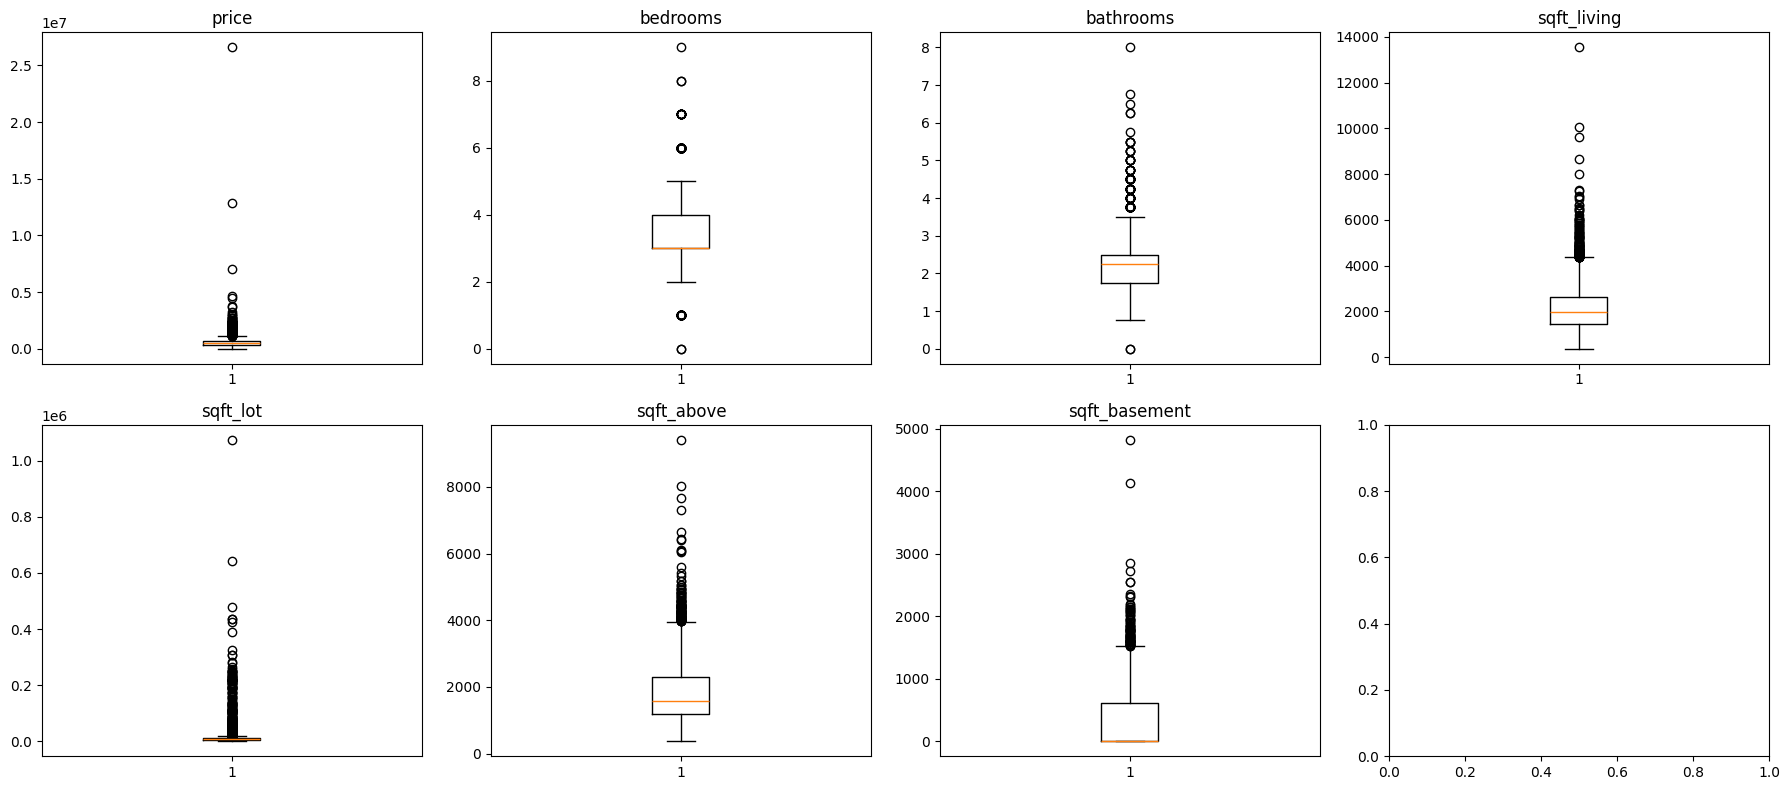

price: 240 outliers
bedrooms: 118 outliers
bathrooms: 141 outliers
sqft_living: 129 outliers
sqft_lot: 541 outliers
sqft_above: 116 outliers
sqft_basement: 82 outliers


In [10]:
# Key columns to check for outliers
cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

# Boxplots to visually see outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(dataset[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# IQR method to count outliers
for col in cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = dataset[(dataset[col] < Q1 - 1.5 * IQR) | (dataset[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

In [11]:

# Step 1: Remove impossible values (bedrooms & bathrooms)
dataset= dataset[dataset['bedrooms'] <= 7]       # remove 8, 9+ bedrooms
dataset= dataset[dataset['bedrooms'] >= 1]       # remove 0 bedrooms
dataset= dataset[dataset['bathrooms'] <= 6]      # remove 7, 8 bathrooms
dataset= dataset[dataset['bathrooms'] >= 0.5]    # remove 0 bathrooms

print(f"After removing impossible values: {dataset.shape}")

# Step 2: Cap outliers using IQR (Winsorization) for remaining columns
cols_to_cap = ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

for col in cols_to_cap:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    dataset[col] = dataset[col].clip(lower=lower, upper=upper)
    print(f"{col} → capped at [{lower:.0f}, {upper:.0f}]")

print(f"\nFinal shape: {dataset.shape}")
print(dataset[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']].describe())

After removing impossible values: (4590, 15)
price → capped at [-171938, 1146562]
sqft_living → capped at [-265, 4335]
sqft_lot → capped at [-4000, 20000]
sqft_above → capped at [-475, 3965]
sqft_basement → capped at [-900, 1500]

Final shape: (4590, 15)
              price     bedrooms    bathrooms  sqft_living      sqft_lot
count  4.590000e+03  4590.000000  4590.000000  4590.000000   4590.000000
mean   5.158295e+05     3.396950     2.155828  2109.796078   8923.958824
std    2.596475e+05     0.895347     0.767152   861.295933   5380.094530
min    0.000000e+00     1.000000     0.750000   370.000000    638.000000
25%    3.225000e+05     3.000000     1.750000  1460.000000   5000.000000
50%    4.600000e+05     3.000000     2.250000  1970.000000   7683.000000
75%    6.521250e+05     4.000000     2.500000  2610.000000  11000.000000
max    1.146562e+06     7.000000     5.750000  4335.000000  20000.000000


In [12]:
# Fix: lower bound should never go below 0 for size columns
cols_to_cap = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

for col in cols_to_cap:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0, Q1 - 1.5 * IQR)   # ← never allow negative
    upper = Q3 + 1.5 * IQR
    
    dataset[col] = dataset[col].clip(lower=lower, upper=upper)
    print(f"{col} → capped at [{lower:.0f}, {upper:.0f}]")

print(dataset[['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']].min())

sqft_living → capped at [0, 4335]
sqft_lot → capped at [0, 20000]
sqft_above → capped at [0, 3965]
sqft_basement → capped at [0, 1500]
sqft_living      370
sqft_lot         638
sqft_above       370
sqft_basement      0
dtype: int64


In [13]:
dataset = dataset[dataset['price'] > 0]
print(f"Shape after removing 0-price rows: {dataset.shape}")

Shape after removing 0-price rows: (4542, 15)


In [14]:
# Age of house
dataset['house_age'] = 2024 - dataset['yr_built']

# Was it renovated?
dataset['is_renovated'] = (dataset['yr_renovated'] > 0).astype(int)

#Drop original years columns
dataset=dataset.drop(columns=['yr_built','yr_renovated'])

In [15]:
#Separating the features and target
x = dataset.drop("price", axis=1)
y = dataset["price"]

#Train/Test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# Combine x_train and y_train temporarily for encoding
train_temp = pd.concat([x_train, y_train], axis=1)

# Target Encoding using train data only
city_mean = train_temp.groupby('city')['price'].mean()
statezip_mean = train_temp.groupby('statezip')['price'].mean()

# Apply encoding + handle unseen values (NaN fix)
x_train['city'] = x_train['city'].map(city_mean)
x_test['city'] = x_test['city'].map(city_mean).fillna(city_mean.mean())

x_train['statezip'] = x_train['statezip'].map(statezip_mean)
x_test['statezip'] = x_test['statezip'].map(statezip_mean).fillna(statezip_mean.mean())

In [16]:
#Scaling on train data only
scaler=StandardScaler()
x_train=pd.DataFrame(scaler.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(scaler.transform(x_test),columns=x_test.columns)


In [17]:
# Train Linear Regression Model
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Evaluate Linear Regression Model (R² Score)
print(f"Linear Regression R² Score: {lr_model.score(x_test, y_test)*100:.2f}%")

Linear Regression R² Score: 80.26%


In [19]:
# Train Gradient Boosting Model with tuned hyperparameters
gb_model = GradientBoostingRegressor(
    n_estimators=500,      # more trees (default was 100)
    learning_rate=0.05,    # slower learning = better accuracy
    max_depth=5,           # deeper trees = captures more patterns
    min_samples_split=10,
    random_state=42
)
gb_model.fit(x_train, y_train)
print(f"Gradient Boosting R² Score: {gb_model.score(x_test, y_test)*100:.2f}%") # Evaluate Gradient Boosting Model (R² Score)

Gradient Boosting R² Score: 83.73%


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Generate predictions for both models
y_pred_lr = lr_model.predict(x_test)
y_pred_gb = gb_model.predict(x_test)

# Calculate MAE and RMSE for both models
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("Linear Regression  → MAE:", round(mae_lr, 2), "| RMSE:", round(rmse_lr, 2))
print("Gradient Boosting  → MAE:", round(mae_gb, 2), "| RMSE:", round(rmse_gb, 2))

Linear Regression  → MAE: 80621.62 | RMSE: 113094.68
Gradient Boosting  → MAE: 68062.16 | RMSE: 102687.76


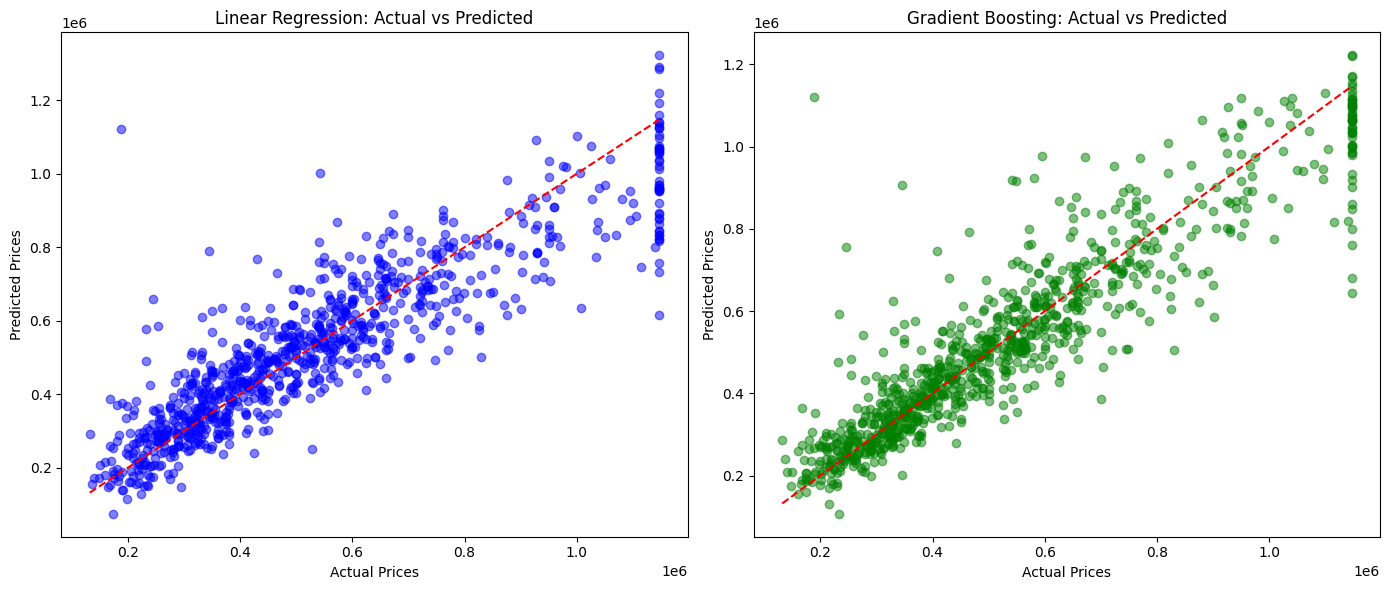

In [23]:
plt.figure(figsize=(14, 6))

# Linear Regression Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted")

# Gradient Boosting Plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_gb, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.tight_layout()
plt.show()

In [24]:
# Feature Importance from Gradient Boosting
feature_importance = pd.Series(gb_model.feature_importances_, index=x_train.columns)
feature_importance.sort_values(ascending=False).head(5)

sqft_living    0.473380
statezip       0.321696
city           0.046480
view           0.032329
sqft_above     0.031881
dtype: float64

## Conclusion

**Linear Regression R² Score: 80%**
**Gradient Boosting R² Score: 83%**

Gradient Boosting outperformed Linear Regression by 3%, making it the better
model for this dataset.

Linear Regression achieved 80% accuracy which is decent, but it struggled to
capture the non-linear relationships between features like square footage,
location, and price.

Gradient Boosting with 500 estimators and a learning rate of 0.05 achieved 83%,
meaning it could explain 83% of the variance in house prices — a solid result
for real estate data.

Key findings:
- sqft_living (47.3%) was the most influential feature — larger homes cost more
- statezip (32.2%) was the second strongest — location heavily impacts price
- city (4.6%), view (3.2%), and sqft_above (3.2%) had smaller but notable impacts